# Propagating orbital uncertainty onto the sky plane

This tutorial shows how to use `Particle.ephemeris(uncertainty=True)` to propagate a
6x6 initial-state covariance matrix through the N-body integration onto the sky plane
via JAX forward-mode automatic differentiation.

We use linear error propagation via the Jacobian:
$$\Sigma_{\text{sky}}(t) = J(t)\, \Sigma_{\text{init}}\, J(t)^\top, \qquad J(t) = \frac{\partial(\text{RA, Dec})}{\partial \mathbf{q}_0}$$

The returned `cov_radec` is in **arcsec$^2$**; `coords` is a standard astropy `SkyCoord`.

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time

from jorbit import Particle
from jorbit.utils.states import CartesianState

RAD2ARCSEC = 180 / np.pi * 3600

First we'll pull (274301) Wikipedia's state from JPL Horizons at 2026-01-01 and build a `Particle`. This makes one network request: 

In [2]:
t0 = Time("2026-01-01")
p = Particle.from_horizons("274301", time=t0)
print(p)
print("t_ref:", p.t_ref)
print("x (AU):", p.cartesian_state.x)
print("v (AU/day):", p.cartesian_state.v)

Particle: 274301
t_ref: 2026-01-01 00:01:09.184
x (AU): [[-1.95958228 -1.38178686 -0.42942657]]
v (AU/day): [[ 0.00770048 -0.00743586 -0.00217952]]


Next, let's admit that we don't know the asteroid's initial state perfectly and express our uncertainty as a covariance matrix. We could use either `CartesianState` or `KeplerianState` here, but we'll use `CartesianState` for now. We'll construct a fresh `CartesianState` from the particle's nominal state but add a diagonal `cov` matrix in (x, y, z, vx, vy, vz).  The values here are intentionally large enough to make the propagated uncertainty visible in the plots.

Note that we use `state.replace(cov=cov_init)` as a shorthand to create a new `CartesianState` with the same nominal state but a different covariance. This is equivalent to `CartesianState(x=state.x, v=state.v, time_reference=state.time_reference, acceleration_func_kwargs=state.acceleration_func_kwargs, cov=cov_init)` but more concise.

In [13]:
sigma_pos = 1e-6  # AU  (~150 km)
sigma_vel = 1e-7  # AU/day  (~0.9 m/s)

cov_init = jnp.diag(
    jnp.array(
        [
            sigma_pos**2,
            sigma_pos**2,
            sigma_pos**2,
            sigma_vel**2,
            sigma_vel**2,
            sigma_vel**2,
        ]
    )
)

# note, there are two equivalent ways to create the new CartesianState:
# we can either 1) write everything out explicitly
new_state = CartesianState(
    x=state.x,
    v=state.v,
    relative_time=state.relative_time,
    time_reference=state.time_reference,
    cov=cov_init,
    acceleration_func_kwargs=state.acceleration_func_kwargs,
)
# or 2) use the `replace` method to only specify the fields we want to change
new_state = p.cartesian_state.replace(cov=cov_init)
print("cov shape:", new_state.cov.shape)

p = Particle(state=new_state)

cov shape: (6, 6)


Now let's run the propagation. Pass the state-with-covariance via `state=` and set `uncertainty=True`.  The return value is a tuple of `coords` (shape `(N,)`, astropy `SkyCoord`) and `cov_radec` (shape `(N, 2, 2)`, units arcsec^2, axis order (RA, Dec)).

In [29]:
times = t0 + np.arange(0, 600, 10) * u.day  # every 10 days for 600 days

result = p.ephemeris(times, "kitt peak", uncertainty=True)

ra = np.array(result[0].ra.rad)  # (N,) radians
dec = np.array(result[0].dec.rad)  # (N,) radians
cov_sky = np.array(result[1])  # (N, 2, 2) arcsec^2

sigma_ra_asec = np.sqrt(cov_sky[:, 0, 0])
sigma_dec_asec = np.sqrt(cov_sky[:, 1, 1])

days = np.arange(0, 600, 10)
print(f"sigma_ra  at t=0:   {sigma_ra_asec[0]:.4f} arcsec")
print(f"sigma_dec at t=0:   {sigma_dec_asec[0]:.4f} arcsec")
print(f"sigma_ra  at t=365: {sigma_ra_asec[-1]:.4f} arcsec")
print(f"sigma_dec at t=365: {sigma_dec_asec[-1]:.4f} arcsec")

sigma_ra  at t=0:   0.0000 arcsec
sigma_dec at t=0:   0.0000 arcsec
sigma_ra  at t=365: 17.0171 arcsec
sigma_dec at t=365: 1.3695 arcsec


We can plot the uncertainty in each dimension over time:

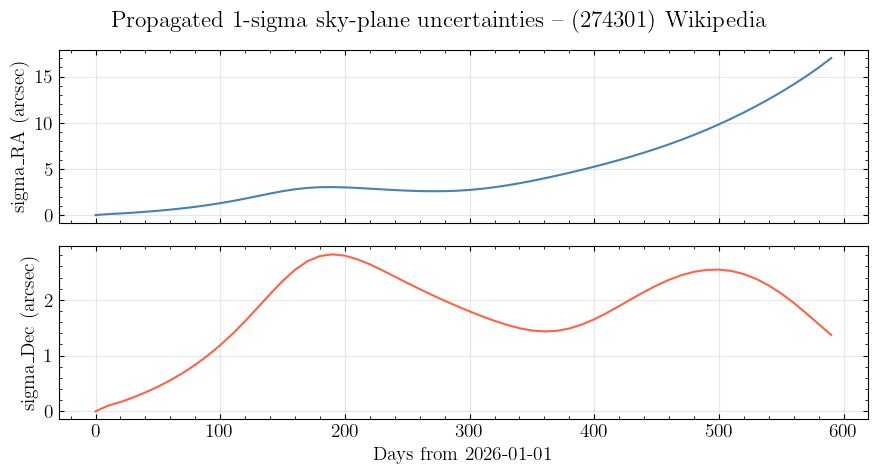

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

axes[0].plot(days, sigma_ra_asec, color="steelblue")
axes[0].set_ylabel("sigma_RA (arcsec)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(days, sigma_dec_asec, color="tomato")
axes[1].set_ylabel("sigma_Dec (arcsec)")
axes[1].set_xlabel("Days from 2026-01-01")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Propagated 1-sigma sky-plane uncertainties -- (274301) Wikipedia", y=0.95)
fig.tight_layout()
plt.show()

We can also illustrate how the position angle and correlation of the sky-plane uncertainty ellipse evolves over time.

`cov_sky` is in *coordinate* `(RA, Dec)` arcsec$^2$ -- the `(0, 0)` entry is the variance of RA itself, not of $\text{RA}\cos(\text{Dec})$. To get a tangent-plane view where both axes are true on-sky angular distances, we transform per-frame by
$$ \Sigma_{\text{tan}} = T\, \Sigma_{\text{sky}}\, T^\top, \qquad T = \mathrm{diag}(\cos(\text{Dec}),\, 1), $$
using the nominal Dec at that time. For Wikipedia near the ecliptic the difference is small (cos(Dec) is close to 1), but applying the transform makes the axis labels honest.

In [31]:
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# Precompute tangent-plane ellipse parameters for every frame.
# cov_sky is in coordinate (RA, Dec) arcsec^2; transform to (RA*cos(Dec), Dec)
# so the ellipse axes are true on-sky angular distances.
ellipse_params = []
for i in range(len(days)):
    T = np.diag([np.cos(dec[i]), 1.0])
    cov_tangent = T @ cov_sky[i] @ T.T
    vals, vecs = np.linalg.eigh(cov_tangent)  # vals ascending
    a = np.sqrt(vals[1])  # major semi-axis (arcsec)
    b = np.sqrt(vals[0])  # minor semi-axis (arcsec)
    angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))  # deg from x-axis
    ellipse_params.append((a, b, angle))

lim = ellipse_params[-1][0] * 1.3  # fix axes to final (largest) ellipse + 30% pad

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel(r"$\Delta$RA cos(Dec) [arcsec]")
ax.set_ylabel(r"$\Delta$Dec [arcsec]")
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.5, zorder=1)
ax.axvline(0, color="gray", lw=0.5, zorder=1)
ax.scatter(0, 0, s=200, c="k", marker="*", zorder=5)
ax.grid(True, alpha=0.3)

a0, b0, ang0 = ellipse_params[0]
ell = Ellipse(
    xy=(0, 0),
    width=2 * a0,
    height=2 * b0,
    angle=ang0,
    facecolor="steelblue",
    edgecolor="steelblue",
    alpha=0.4,
    zorder=2,
)
ax.add_patch(ell)

title = ax.set_title("")
plt.tight_layout()


def update(frame):
    a, b, angle = ellipse_params[frame]
    ell.set_width(2 * a)
    ell.set_height(2 * b)
    ell.set_angle(angle)
    date_str = times[frame].iso[:10]
    title.set_text(f"{date_str}  (day {days[frame]})")
    return (ell,)


anim = FuncAnimation(fig, update, frames=len(days), interval=120, blit=True)
plt.close()

display(HTML(anim.to_jshtml()))

Finally, let's check whether the linear error propagation in `cov_sky` is actually a good approximation at the input `sigma_pos` / `sigma_vel` levels. The Gaussian propagated through the Jacobian is exact for *infinitesimal* perturbations; if the input uncertainties are large enough that nonlinear dynamics matter over the integration window, the linearized `cov_sky` no longer represents the true distribution.

We test this along one direction (perturbing `x[0]`):

1. **Linear prediction.** Compute one column of the Jacobian numerically with a *tiny* perturbation (`tiny = 1e-9` AU, well inside the linear regime). Scaling by `sigma_pos` gives the linear prediction for the sky shift induced by a 1-sigma perturbation in `x[0]`.
2. **Actual nonlinear shift.** Re-integrate with the full `sigma_pos` perturbation applied and measure the actual change in (RA, Dec).

If the two curves track each other, the Gaussian represented by `cov_sky` is honest at this sigma level. If they diverge, the input uncertainty is large enough that linearization is breaking down and the propagated covariance is underestimating tails. (Caveat: this only probes one of the six input directions; perturbations in other coordinates could be more nonlinear.)

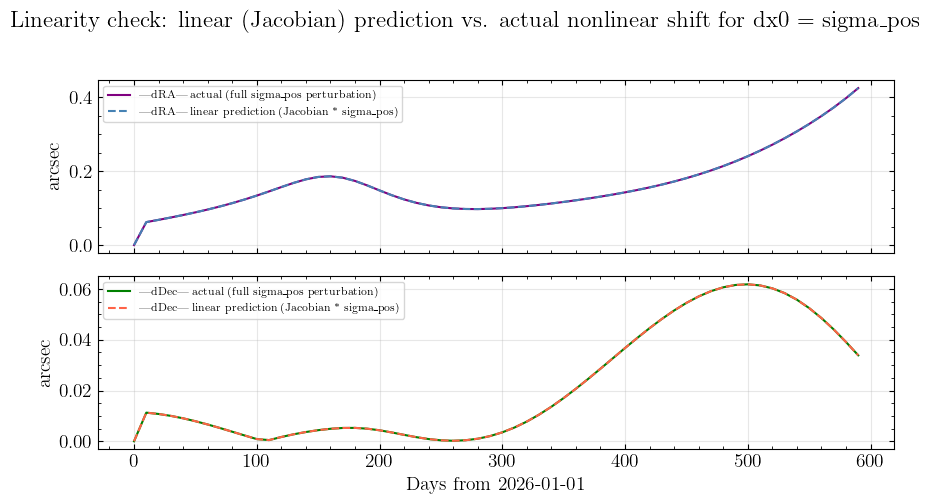

Ratio actual / linear-prediction at t=500:  1.0000008223510262


In [32]:
tiny = 1e-9  # AU (much smaller than sigma_pos, squarely in the linear regime)
cs_tiny = p.cartesian_state.replace(x=p.cartesian_state.x.at[0, 0].add(tiny))
eph_tiny = p.ephemeris(times, "kitt peak", state=cs_tiny)
J_ra_x0 = (np.array(eph_tiny.ra.rad) - ra) / tiny
J_dec_x0 = (np.array(eph_tiny.dec.rad) - dec) / tiny

# Linear (Jacobian-based) prediction of the shift from a sigma_pos perturbation in x[0].
pred_delta_ra_asec = np.abs(J_ra_x0 * sigma_pos) * RAD2ARCSEC
pred_delta_dec_asec = np.abs(J_dec_x0 * sigma_pos) * RAD2ARCSEC

# Actual nonlinear shift from the same sigma_pos perturbation.
cs_pert = p.cartesian_state.replace(x=p.cartesian_state.x.at[0, 0].add(sigma_pos))
eph_pert = p.ephemeris(times, "kitt peak", state=cs_pert)
actual_delta_ra_asec = np.abs(np.array(eph_pert.ra.rad) - ra) * RAD2ARCSEC
actual_delta_dec_asec = np.abs(np.array(eph_pert.dec.rad) - dec) * RAD2ARCSEC

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

axes[0].plot(
    days,
    actual_delta_ra_asec,
    label="|dRA| actual (full sigma_pos perturbation)",
    color="purple",
)
axes[0].plot(
    days,
    pred_delta_ra_asec,
    label="|dRA| linear prediction (Jacobian * sigma_pos)",
    color="steelblue",
    ls="--",
)
axes[0].set_ylabel("arcsec")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    days,
    actual_delta_dec_asec,
    label="|dDec| actual (full sigma_pos perturbation)",
    color="green",
)
axes[1].plot(
    days,
    pred_delta_dec_asec,
    label="|dDec| linear prediction (Jacobian * sigma_pos)",
    color="tomato",
    ls="--",
)
axes[1].set_ylabel("arcsec")
axes[1].set_xlabel("Days from 2026-01-01")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    "Linearity check: linear (Jacobian) prediction vs. actual nonlinear shift for dx0 = sigma_pos",
    y=1.01,
)
fig.tight_layout()
plt.show()

print(
    "Ratio actual / linear-prediction at t=500: ",
    actual_delta_ra_asec[-1] / pred_delta_ra_asec[-1],
)